# NB05b -- Dataset Builder (Per-Tier Parquets)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


>
> This program is free software: you can redistribute it and/or modify
> the Free Software Foundation, either version 3 of the License, or
> (at your option) any later version.
>
> This program is distributed in the hope that it will be useful,
> but WITHOUT ANY WARRANTY; without even the implied warranty of
> MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
>
> along with this program. If not, see <https://www.gnu.org/licenses/>.

| Field | Value |
|---|---|
| Notebook | `05bV1_bda_Dataset_Builder_v18.ipynb` |
| Version | `v18` |
| Pipeline position | Feature extraction. After NB05a (data stack). Before NB06-NB11 (analysis + ML). |
| License | Code: AGPL-3.0-or-later -- see [LICENSE](../LICENSE) |
| Last validated | 2026-04-15 |

## Narrative

**This is where rasters become tabular ML features.** NB05b reads aligned TIFs from the
data stack (NB05a), performs zonal statistics per building footprint (from
`building_labels.tif`), and writes per-tier parquet files that NB06-NB11 consume.

### Per-Tier Architecture

NB05b builds **one parquet per tier per dataset type**. Downstream notebooks use
`load_tier_parquets(FMT, TIER_SELECTION)` from global_setup to concat tiers at runtime.
This design allows: (a) processing T0 first for fast iteration, then T0+T1 overnight,
then full 21-city run; (b) adding new tiers without reprocessing existing ones;
(c) loading only needed tiers in memory-constrained environments.

### Parquet Types

| Parquet | Format | Content | Rows |
|---------|--------|---------|------|
| `bda_buildings_t{tier}` | Wide | Building metadata: area, perimeter, damage_binary, ems98, city, fold | 1 per building |
| `bda_scene_card_t{tier}` | Long | Per-date CARD VV/VH zonal stats per building | 1 per building x date |
| `bda_scene_ms_t{tier}` | Long | Per-date MS band zonal stats per building | 1 per building x date |
| `bda_scene_ms_derived_t{tier}` | Long | Per-date spectral index zonal stats (NDVI, NBR, etc.) | 1 per building x date |
| `bda_scene_coh_t{tier}` | Long | Per-date COH VV/VH zonal stats per building | 1 per building x date |
| `bda_rolling_card_roll{N}_t{tier}` | Long | Per-date rolling mean CARD per building | 1 per building x date |
| `bda_rolling_coh_roll{N}_t{tier}` | Long | Per-date rolling mean COH per building | 1 per building x date |
| `bda_rolling_roll{N}_t{tier}` | Wide | Baseline + rolling assessment stats (7 stats) | 1 per building |
| `bda_block_stats_t{tier}` | Wide | Dietrich 3-month block stats (blk_pre, blk01..N) | 1 per building |
| `bda_product_prepost_t{tier}` | Wide | Pre/post composite features per building | 1 per building |

**Long-format** parquets (scene/rolling) have one row per building per date -- used for
temporal analysis in NB08 and obs-indexed datasets in NB05b-temporal.
**Wide-format** parquets (buildings/rolling_stats/block_stats/prepost) have one row per
building -- used directly by NB09a-e ML experiments.

### Zonal Statistics Method

For each building: read `building_labels.tif` to get pixel mask for that building ID,
read the corresponding product TIF, extract pixel values within the mask, compute
mean (and optionally min/max/std). Buildings with fewer than `MIN_PIXELS=3` valid
pixels are excluded (below Sentinel resolution limit).

### GroupKFold

City-level GroupKFold assignment ensures no city appears in both train and test folds.
Stored as `groupkfold.parquet` and joined to building metadata at ML time via
`building_id`. This is the methodologically correct spatial CV (Roberts 2017, Ploton 2020).

## Scientific Rationale
Period aggregation (wide-format parquets) eliminates structural NaN -- the single most
impactful design change identified in NB09e. Per-building zonal statistics with
building_labels.tif ensure features are spatially consistent with the damage labels.
Per-tier parquets enable the GroupKFold leakage comparison: NB09a random CV vs
GroupKFold on the same features produces the publishable leakage delta.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| Aligned TIFs | `STACK_ROOT/{city}/` (NB05a) | GeoTIFF |
| `building_labels.tif` per city | `STACK_ROOT/{city}/` (NB03e) | GeoTIFF (int32) |
| `damage_mask.tif` per city | `STACK_ROOT/{city}/` (NB03e) | GeoTIFF (int8) |
| `AOI.geojson` per city | NB01b | GeoJSON (building metadata) |
| `bda.sqlite` | NB05a | Catalog for product discovery |
| `cities_config.json` | Manual | Tier assignments |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Per-tier parquets (10+ types) | `DATASET_ROOT/bda_*_t{tier}.parquet` | NB06-NB11 via `load_tier_parquets()` |
| `groupkfold.parquet` | `DATASET_ROOT/` | NB09a-e (spatial CV) |

## Cell Structure

| Cell | ID | What | Lines | Status |
|------|----|------|-------|--------|
| 0-1 | -- | Documentation + parquet overview | -- | -- |
| 2 | Cell 3 | Config (TIER, MIN_PIXELS, per-parquet FORCE_RERUN) | 19 | Config |
| 3 | Cell 4 | Load global_setup | 11 | Config |
| 4-5 | Cell 5 | Shared helpers + city discovery (per-tier grouping) | 128 | **Core** |
| 6-7 | BUILDINGS | Building metadata parquet (1 row per building) | 77 | **Core** |
| 8-9 | SCENE-CARD | Per-date CARD VV/VH zonal stats | 65 | **Core** |
| 10-11 | SCENE-MS | Per-date MS band zonal stats | 77 | **Core** |
| 12-13 | SCENE-MS-DERIVED | Per-date spectral index zonal stats | 92 | **Core** |
| 14-15 | SCENE-COH | Per-date COH VV/VH zonal stats | 91 | **Core** |
| 16-17 | ROLLING-CARD | Per-date rolling CARD (per window per tier) | 69 | **Core** |
| 18-19 | ROLLING-COH | Per-date rolling COH (per window per tier) | 68 | **Core** |
| 20-21 | ROLLING-STATS | Wide baseline + rolling assessment stats | 90 | **Core** |
| 22-23 | BLOCK-STATS | Dietrich 3-month block stats | 105 | **Core** |
| 24-25 | PREPOST | Pre/post composite features (wide) | 114 | **Core** |
| 26-27 | GROUPKFOLD | City-level fold assignment | 10 | **Core** |
| 28-29 | PREPOST-SINGLE | Single-scene RGB + CARD pre/post | 210 | **Core** |
| 30-31 | COH-DROP | COH drop accumulator parquet | 70 | **Core** |
| 32-33 | VALIDATE | Check all per-tier parquets | 46 | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.4 Dataset Construction -- Feature Extraction | All parquet cells | Zonal statistics method, per-tier design |
| 3.4 Dataset Construction -- Spatial CV | GROUPKFOLD | GroupKFold by city (Roberts 2017) |
| 3.4 Dataset Construction -- Parquet Architecture | Cell 1 MD | Long vs wide format rationale |

## Per-tier parquets
NB05b builds one parquet per tier per dataset type.
NB06+ uses `load_tier_parquets(FMT, TIER_SELECTION)` to concat at runtime.

Parquets per tier (e.g. `_t0.parquet`, `_t1.parquet`):
- `bda_buildings_t{tier}` (building metadata)
- `bda_scene_card/ms/ms_derived/coh_t{tier}` (per-date long-format)
- `bda_rolling_card/coh_roll{N}_t{tier}` (per-date rolling, long-format)
- `bda_rolling_roll{N}_t{tier}` (baseline + rolling assessment stats, wide)
- `bda_block_stats_t{tier}` (baseline + Dietrich 3-month blocks, wide)
- `bda_product_prepost_t{tier}` (CARD+COH+MS pre/post, wide)


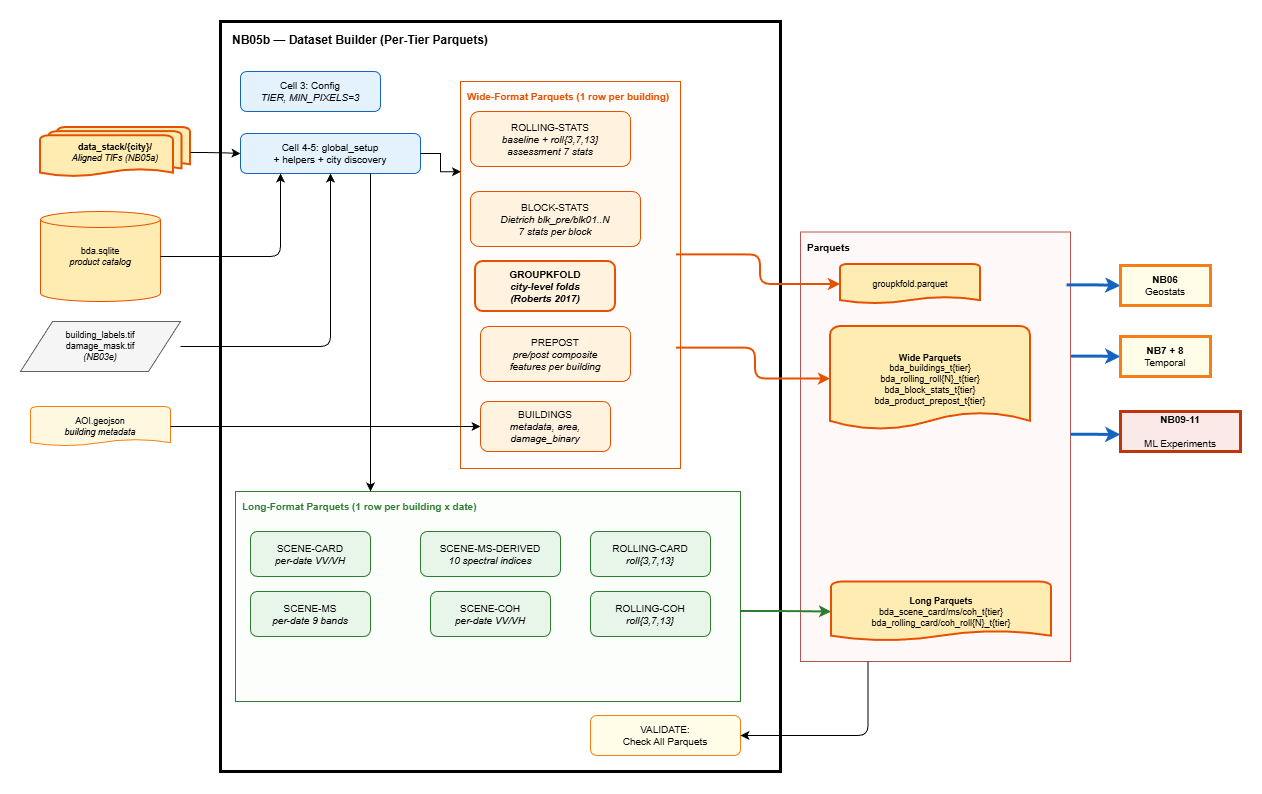

In [1]:
# @title CELL 3: NB05b CONFIG
TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True
MIN_PIXELS = 3

# per-parquet force rerun (False = skip if parquet exists and is valid)
FR_BUILDINGS = False
FR_SCENE_CARD = True
FR_SCENE_MS = True
FR_SCENE_MS_DERIVED = True
FR_SCENE_COH = True
FR_ROLLING_CARD = True
FR_ROLLING_COH = True
FR_ROLLING_STATS = True
FR_BLOCK_STATS = True
FR_PREPOST = True
FR_GROUPKFOLD = True
FR_PREPOST_SINGLE = True
FR_COH_DROP = True


In [2]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


BDA GLOBAL SETUP
Started: 2026-04-15 09:44:18
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:536: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.4/7452.0 GB (6539.6 GB free)
  GDrive (F:)     634.1/3726.0 GB (3091.9 GB free)
  Local data      11386.6/14901.9 GB (3515.3 GB free)
  Data stack      634.1/3726.0 GB (3091.9 GB free)
  WSL ext4        94.1/1006.9 GB (861.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_bb

# SHARED: Load helpers + discover cities (grouped by tier)

In [3]:
# @title CELL 5: SHARED HELPERS + CITY DISCOVERY (PER-TIER)
import sys, importlib, re, time, gc, json
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path
from datetime import datetime

DATASET_ROOT_V1.mkdir(parents=True, exist_ok=True)

from stack_catalog import BDACatalog, parse_feature_name
cat = BDACatalog(CATALOG_DB)
print(f"  Catalog: {CATALOG_DB}")


import stack_features
importlib.reload(stack_features)
from stack_features import extract_zonal_stats_from_labels

from stack_catalog import BDACatalog
# ---- discover ML-ready cities ----
manifest_path = STACK_ROOT / "data_stack_manifest.json"
with open(manifest_path) as f:
    manifest = json.load(f)

city_meta = {}
for city_name, info in sorted(manifest.get("cities", {}).items()):
    tier = info.get("tier", 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city_name not in (CITY_SELECTION if isinstance(CITY_SELECTION, list) else [CITY_SELECTION]):
        continue
    if not info.get("ready_ml", False):
        continue
    ref_path = STACK_ROOT / city_name / "reference_grid.json"
    if not ref_path.exists():
        continue
    aoi_row = load_aoi(city_name)
    city_meta[city_name] = {
        "battle_start": str(aoi_row.get("battle_start", ""))[:10],
        "battle_stop": str(aoi_row.get("battle_stop", "") or "")[:10],
        "tier": int(aoi_row.get("tier", 99)),
        "manifest": info,
    }

CITIES = sorted(city_meta.keys())

# ---- GROUP CITIES BY TIER ----
from collections import defaultdict
TIER_CITIES = defaultdict(list)
for c in CITIES:
    TIER_CITIES[city_meta[c]['tier']].append(c)
TIER_CITIES = dict(sorted(TIER_CITIES.items()))

print(f"Cities: {len(CITIES)} across {len(TIER_CITIES)} tiers")
for tier, tc in TIER_CITIES.items():
    print(f"  Tier {tier}: {len(tc)} cities")
    for c in tc:
        m = city_meta[c]
        print(f"    {c:<22s} battle={m['battle_start']}")

# ---- helper: load building labels + metadata for one city ----
def load_city_buildings(city_name):
    city_stack = STACK_ROOT / city_name
    labels_path = city_stack / "building_labels.tif"
    meta_path = city_stack / "building_raster_meta.json"
    if not labels_path.exists():
        return None, None, None, None
    with rasterio.open(labels_path) as src:
        label_array = src.read(1)
        ref_shape = (src.height, src.width)
    with open(meta_path) as f:
        bldg_meta = json.load(f)
    n_buildings = bldg_meta["n_buildings"]
    return label_array, ref_shape, n_buildings, bldg_meta

# ---- helper: assign period label from date + battle dates ----
# Simple 3-period model for scene parquets (not Dietrich sub-periods).
# stack_loader.assign_periods uses Dietrich 30-day/180-day sub-windows
# which belong in NB07, not here.
def get_period_label(date_str, battle_start, battle_stop):
    d_clean = str(date_str).replace('-', '')[:8]
    dt = datetime.strptime(d_clean, '%Y%m%d')
    bs = datetime.strptime(str(battle_start)[:10], '%Y-%m-%d')
    if dt < bs:
        return 'prebattle'
    be = None
    if battle_stop and str(battle_stop).lower() not in ('', 'none', 'nat', 'ongoing'):
        be = datetime.strptime(str(battle_stop)[:10], '%Y-%m-%d')
    if be and dt > be:
        return 'postbattle'
    return 'crossbattle'

# ---- helper: assign timestep index ----
def assign_timesteps(dates, battle_start_str):
    bs = datetime.strptime(battle_start_str, "%Y-%m-%d")
    dated = [(d, datetime.strptime(d, "%Y%m%d")) for d in dates]
    pre = sorted([(d, dt) for d, dt in dated if dt < bs], key=lambda x: x[1])
    post = sorted([(d, dt) for d, dt in dated if dt >= bs], key=lambda x: x[1])
    ts = {}
    for i, (d, dt) in enumerate(pre):
        ts[d] = -(len(pre) - i)
    for i, (d, dt) in enumerate(post):
        ts[d] = i
    return ts

# ---- helper: read + pad + nodata-mask a TIF ----
def read_tif_aligned(path, ref_shape):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        if data.shape != ref_shape:
            padded = np.full(ref_shape, np.nan, dtype=np.float32)
            h, w = min(data.shape[0], ref_shape[0]), min(data.shape[1], ref_shape[1])
            padded[:h, :w] = data[:h, :w]
            data = padded
        nd = src.nodata
        if nd is not None:
            try:
                nd_f = float(nd)
                if not np.isnan(nd_f):
                    data[data == nd_f] = np.nan
            except (ValueError, TypeError):
                pass
    return data


# ---- COLUMN ROLE DEFINITIONS (source of truth for all parquets) ----
# These sets determine what goes into bda.sqlite as feature/label/metadata/id.
# NB06+ reads from sqlite, never guesses.
ID_COLS = {'building_id'}
LABEL_COLS = {'damage_binary', 'damage_label', 'damage', 'ems98_grade'}
META_COLS_SET = {
    'city', 'tier', 'battle_start', 'battle_stop', 'conflict_ongoing',
    'has_card', 'has_coh', 'has_ms',
    'unosat_id', 'unosat_date', 'unosat_ep',
    'match_method', 'match_distance', 'in_aoi',
    'height', 'num_floors', 'roof_height',
    'area_m2', 'centroid_x', 'centroid_y', 'n_pixels',
    'date', 'date1', 'date2', 'timestep', 'period_label',
}

def build_role_overrides(columns):
    """Build {col: role} dict for register_parquet_columns."""
    overrides = {}
    for col in columns:
        if col in ID_COLS:
            overrides[col] = 'id'
        elif col in LABEL_COLS:
            overrides[col] = 'label'
        elif col in META_COLS_SET:
            overrides[col] = 'metadata'
        # else: default 'feature' from parse_feature_name
    return overrides

print("  Roles: ID_COLS, LABEL_COLS, META_COLS_SET, build_role_overrides()")

# ---- helper: log dataset profile to JSON for NB06 discovery ----
PROFILE_DIR = DATASET_ROOT_V1 / 'dataset_profiles'
PROFILE_DIR.mkdir(parents=True, exist_ok=True)

def log_dataset_profile(df, parquet_name):
    """Write a JSON profile for one parquet. NB06 reads these."""
    from datetime import datetime as _dt
    num_cols = [c for c in df.columns if df[c].dtype.kind in ('f', 'i', 'u')]
    non_feature = ID_COLS | LABEL_COLS | META_COLS_SET
    feat_cols = [c for c in num_cols if c not in non_feature]

    profile = {
        'parquet_name': parquet_name,
        'timestamp': _dt.now().isoformat(),
        'n_rows': int(len(df)),
        'n_cols': int(len(df.columns)),
        'n_features': len(feat_cols),
        'n_cities': int(df['city'].nunique()) if 'city' in df.columns else 0,
        'nan_rate_overall': float(df[feat_cols].isna().mean().mean()) if feat_cols else 0.0,
    }

    if 'city' in df.columns:
        profile['buildings_per_city'] = {
            c: int(n) for c, n in df['city'].value_counts().items()
        }

    if 'city' in df.columns and 'damage_binary' in df.columns:
        dr = df.groupby('city')['damage_binary'].mean()
        profile['damage_rate_per_city'] = {c: float(v) for c, v in dr.items()}

    if 'city' in df.columns and feat_cols:
        nan_per_city = df.groupby('city')[feat_cols].apply(
            lambda g: g.isna().mean().mean()
        )
        profile['nan_rate_per_city'] = {c: float(v) for c, v in nan_per_city.items()}

    out = PROFILE_DIR / f'{parquet_name}.json'
    with open(out, 'w') as f:
        json.dump(profile, f, indent=2)

    # per-feature stats
    from scipy import stats as _stats
    feat_records = []
    for col in feat_cols:
        s = df[col]
        n_nan = int(s.isna().sum())
        nan_pct = 100.0 * n_nan / len(s) if len(s) > 0 else 0.0
        valid = s.dropna()
        rec = {'feature': col, 'nan_pct': round(nan_pct, 2)}
        if len(valid) > 1:
            m = float(valid.mean())
            sd = float(valid.std())
            rec['mean'] = round(m, 6)
            rec['std'] = round(sd, 6)
            rec['min'] = round(float(valid.min()), 6)
            rec['max'] = round(float(valid.max()), 6)
            rec['cv'] = round(sd / abs(m), 4) if abs(m) > 1e-12 else 0.0
            rec['skewness'] = round(float(_stats.skew(valid, nan_policy='omit')), 4)
            rec['kurtosis'] = round(float(_stats.kurtosis(valid, nan_policy='omit')), 4)
        else:
            rec.update({'mean': None, 'std': None, 'min': None, 'max': None,
                        'cv': None, 'skewness': None, 'kurtosis': None})
        feat_records.append(rec)

    feat_out = PROFILE_DIR / f'{parquet_name}_features.json'
    with open(feat_out, 'w') as f:
        json.dump(feat_records, f, indent=1)
    print(f"    profile -> {out.name} + {feat_out.name} ({len(feat_records)} features)")

print(f"  PROFILE_DIR: {PROFILE_DIR}")


  Catalog: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
Cities: 21 across 3 tiers
  Tier 0: 4 cities
    Lysychansk             battle=2022-06-25
    Mariupol               battle=2022-02-24
    Rubizhne               battle=2022-03-04
    Sievierodonetsk        battle=2022-05-05
  Tier 1: 11 cities
    Borodyanka             battle=2022-02-28
    Bucha                  battle=2022-02-27
    Chernihiv              battle=2022-02-24
    Dmytrivka              battle=2022-02-27
    Hostomel               battle=2022-02-24
    Irpin                  battle=2022-02-27
    Makariv                battle=2022-02-28
    Moschun                battle=2022-02-27
    Okhtyrka               battle=2022-02-24
    Trostianets            battle=2022-03-01
    Volnovakha             battle=2022-02-24
  Tier 2: 6 cities
    Avdiivka               battle=2022-02-24
    Chornobaivka           battle=2022-02-24
    Kharkiv                battle=2022-02-24
    Kherson                battle=2022-03-02

# CELL: BUILDINGS METADATA PARQUET (per tier)

In [4]:
# @title CELL: bda_buildings_t{tier}.parquet
# One row per building per tier.
for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_BUILDINGS_TIER_FMT.format(tier=tier))
    if not FR_BUILDINGS and out_path.exists():
        _sz = out_path.stat().st_size / 1e6
        print(f"  bda_buildings_t{tier}: exists ({_sz:.1f} MB), skip")
        continue

    t0 = time.time()
    print(f"\n--- Tier {tier}: {len(tier_cities)} cities ---")

    GEOJSON_KEEP_COLS = {
        'damage', 'damage_label', 'damage_binary', 'ems98_grade',
        'unosat_id', 'unosat_date', 'unosat_ep',
        'match_method', 'match_distance', 'in_aoi',
        'height', 'num_floors', 'roof_height',
        'geometry',
    }
    NUMERIC_CAST = ['damage_binary', 'damage_label', 'damage', 'ems98_grade',
                    'height', 'num_floors', 'roof_height', 'match_distance', 'in_aoi']

    all_bldg = []
    for city_name in tier_cities:
        city_stack = STACK_ROOT / city_name
        bldg_path = city_stack / "buildings_overture_with_damage.geojson"
        if not bldg_path.exists():
            bldg_path = city_stack / "buildings_overture.geojson"
        if not bldg_path.exists():
            continue

        ref_path = city_stack / "reference_grid.json"
        with open(ref_path) as f:
            ref = json.load(f)

        gdf = gpd.read_file(bldg_path)
        keep = [c for c in GEOJSON_KEEP_COLS if c in gdf.columns]
        gdf = gdf[keep].copy()
        gdf = gdf.to_crs(f"EPSG:{ref['utm_epsg']}")

        gdf['city'] = city_name
        gdf['building_id'] = [f"{city_name}_{i}" for i in range(len(gdf))]
        gdf['area_m2'] = gdf.geometry.area
        gdf['centroid_x'] = gdf.geometry.centroid.x
        gdf['centroid_y'] = gdf.geometry.centroid.y

        for col in NUMERIC_CAST:
            if col in gdf.columns:
                gdf[col] = pd.to_numeric(gdf[col], errors='coerce')

        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is not None:
            pixel_counts = np.bincount(label_array.ravel(), minlength=n_buildings + 1)[1:]
            gdf['n_pixels'] = pixel_counts

        meta = city_meta[city_name]
        gdf['tier'] = meta['tier']
        gdf['battle_start'] = meta['battle_start']
        gdf['battle_stop'] = meta['battle_stop']
        conflict_ongoing = meta['battle_stop'] in ('', 'ongoing', None, 'None', 'NaT')
        gdf['conflict_ongoing'] = conflict_ongoing

        info = meta['manifest']
        gdf['has_card'] = bool(info.get('has_card', False))
        gdf['has_coh'] = bool(info.get('has_coh', False))
        gdf['has_ms'] = bool(info.get('has_ms', False))

        gdf_flat = gdf.drop(columns=['geometry'], errors='ignore')
        all_bldg.append(gdf_flat)
        print(f"  {city_name}: {len(gdf)} buildings")

    if all_bldg:
        df_bldg = pd.concat(all_bldg, ignore_index=True)
        df_bldg.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_buildings_t{tier}', df_bldg.columns, role_overrides=build_role_overrides(df_bldg.columns))
        print(f"  Saved: {out_path.name} ({len(df_bldg)} buildings, {len(df_bldg.columns)} cols, {time.time()-t0:.0f}s)")
        log_dataset_profile(df_bldg, f'bda_buildings_t{tier}')




--- Tier 0: 4 cities ---
  Lysychansk: 47169 buildings
  Mariupol: 119107 buildings
  Rubizhne: 16687 buildings
  Sievierodonetsk: 14151 buildings
  Saved: bda_buildings_t0.parquet (197114 buildings, 26 cols, 14s)
    profile -> bda_buildings_t0.json + bda_buildings_t0_features.json (0 features)

--- Tier 1: 11 cities ---
  Borodyanka: 49969 buildings
  Bucha: 17367 buildings
  Chernihiv: 58626 buildings
  Dmytrivka: 13650 buildings
  Hostomel: 19798 buildings
  Irpin: 17686 buildings
  Makariv: 7742 buildings
  Moschun: 20565 buildings
  Okhtyrka: 27603 buildings
  Trostianets: 18656 buildings
  Volnovakha: 13888 buildings
  Saved: bda_buildings_t1.parquet (265550 buildings, 26 cols, 17s)
    profile -> bda_buildings_t1.json + bda_buildings_t1_features.json (0 features)

--- Tier 2: 6 cities ---
  Avdiivka: 13360 buildings
  Chornobaivka: 10829 buildings
  Kharkiv: 213845 buildings
  Kherson: 10829 buildings
  Kramatorsk: 58518 buildings
  Mykolaiv: 137326 buildings
  Saved: bda_buil

# CELL: PER-DATE CARD SCENES (per tier)

In [5]:
# @title CELL: bda_scene_card_t{tier}.parquet
for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_SCENE_CARD_TIER_FMT.format(tier=tier))
    if not FR_SCENE_CARD and out_path.exists():
        _sz = out_path.stat().st_size / 1e6
        print(f"  bda_scene_card_t{tier}: exists ({_sz:.1f} MB), skip")
        continue

    t0 = time.time()
    print(f"\n--- Tier {tier} CARD ---")
    rows = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue
        meta = city_meta[city_name]
        card_dir = STACK_ROOT / city_name / "SAR_CARD" / "flat"
        if not card_dir.exists():
            continue

        dates = set()
        for f in card_dir.glob("s1__vv__*.tif"):
            m = re.search(r'__(\d{8})\.tif$', f.name)
            if m:
                dates.add(m.group(1))

        ts_map = assign_timesteps(sorted(dates), meta['battle_start'])

        for date_str in sorted(dates):
            feats = {}
            for pol in ['vv', 'vh']:
                path = card_dir / f"s1__{pol}__{date_str}.tif"
                if not path.exists():
                    # orbit-safe fallback: s1__vv__o094__20220115.tif
                    candidates = list(card_dir.glob(f"s1__{pol}__o*__{date_str}.tif"))
                    if candidates:
                        path = candidates[0]
                    else:
                        continue
                data = read_tif_aligned(path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, f"s1__{pol}", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

            if not feats:
                continue

            period = get_period_label(date_str, meta['battle_start'], meta['battle_stop'])
            timestep = ts_map.get(date_str, 0)
            bids = [f"{city_name}_{i}" for i in range(n_buildings)]

            date_df = pd.DataFrame(feats)
            date_df['building_id'] = bids
            date_df['city'] = city_name
            date_df['date'] = date_str
            date_df['timestep'] = timestep
            date_df['period_label'] = period
            rows.append(date_df)

        print(f"  {city_name}: {len(dates)} dates")

    if rows:
        df = pd.concat(rows, ignore_index=True)
        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_scene_card_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols, {time.time()-t0:.0f}s)")
        log_dataset_profile(df, f'bda_scene_card_t{tier}')
    else:
        print(f"  No CARD scenes for tier {tier}")

    gc.collect()



--- Tier 0 CARD ---
  Lysychansk: 8 dates
  Mariupol: 14 dates
  Rubizhne: 13 dates
  Sievierodonetsk: 12 dates
  Saved: bda_scene_card_t0.parquet (2431593 rows, 11 cols, 37s)
    profile -> bda_scene_card_t0.json + bda_scene_card_t0_features.json (6 features)

--- Tier 1 CARD ---
  Borodyanka: 10 dates
  Bucha: 9 dates
  Chernihiv: 10 dates
  Dmytrivka: 9 dates
  Hostomel: 10 dates
  Irpin: 10 dates
  Makariv: 9 dates
  Moschun: 10 dates
  Okhtyrka: 10 dates
  Trostianets: 9 dates
  Volnovakha: 8 dates
  Saved: bda_scene_card_t1.parquet (2570309 rows, 11 cols, 67s)
    profile -> bda_scene_card_t1.json + bda_scene_card_t1_features.json (6 features)

--- Tier 2 CARD ---
  Avdiivka: 65 dates
  Chornobaivka: 28 dates
  Kharkiv: 24 dates
  Kherson: 28 dates
  Kramatorsk: 125 dates
  Mykolaiv: 12 dates
  Saved: bda_scene_card_t2.parquet (15569766 rows, 11 cols, 179s)
    profile -> bda_scene_card_t2.json + bda_scene_card_t2_features.json (6 features)


# CELL: PER-DATE MS SCENES (per tier)

In [ ]:
# @title CELL: bda_scene_ms_t{tier}.parquet
MS_BANDS = ['b02', 'b03', 'b04', 'b05', 'b07', 'b08', 'b11', 'b12', 'b8a']
MS_AUX = ['scl', 'cloud_mask', 'visibility']

for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_SCENE_MS_TIER_FMT.format(tier=tier))
    if not FR_SCENE_MS and out_path.exists():
        _sz = out_path.stat().st_size / 1e6
        print(f"  bda_scene_ms_t{tier}: exists ({_sz:.1f} MB), skip")
        continue

    t0 = time.time()
    print(f"\n--- Tier {tier} MS ---")
    rows = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue
        meta = city_meta[city_name]
        ms_dir = STACK_ROOT / city_name / "multispectral" / "flat"
        if not ms_dir.exists():
            continue

        dates = set()
        for f in ms_dir.glob("s2__b02__*.tif"):
            m = re.search(r'__(\d{8})\.tif$', f.name)
            if m:
                dates.add(m.group(1))

        ts_map = assign_timesteps(sorted(dates), meta['battle_start'])

        for date_str in sorted(dates):
            feats = {}
            for band in MS_BANDS:
                path = ms_dir / f"s2__{band}__{date_str}.tif"
                if not path.exists():
                    continue
                data = read_tif_aligned(path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, f"s2__{band}", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

            for aux in MS_AUX:
                path = ms_dir / f"s2__{aux}__{date_str}.tif"
                if not path.exists():
                    continue
                data = read_tif_aligned(path, ref_shape)
                is_cat = aux == 'scl'
                stats = extract_zonal_stats_from_labels(label_array, data, f"s2__{aux}", n_buildings, is_landuse=is_cat, min_pixels=MIN_PIXELS)
                feats.update(stats)

            if not feats:
                continue

            period = get_period_label(date_str, meta['battle_start'], meta['battle_stop'])
            timestep = ts_map.get(date_str, 0)
            bids = [f"{city_name}_{i}" for i in range(n_buildings)]

            date_df = pd.DataFrame(feats)
            date_df['building_id'] = bids
            date_df['city'] = city_name
            date_df['date'] = date_str
            date_df['timestep'] = timestep
            date_df['period_label'] = period
            rows.append(date_df)

        print(f"  {city_name}: {len(dates)} MS dates")

    if rows:
        df = pd.concat(rows, ignore_index=True)
        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_scene_ms_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols, {time.time()-t0:.0f}s)")
        log_dataset_profile(df, f'bda_scene_ms_t{tier}')
    else:
        print(f"  No MS scenes for tier {tier}")

    gc.collect()



--- Tier 0 MS ---
  Lysychansk: 11 MS dates


# CELL: PER-DATE MS DERIVED (per tier)

In [ ]:
# @title CELL: bda_scene_ms_derived_t{tier}.parquet
KNOWN_INDICES = ['ndvi', 'nbr', 'bsi', 'savi', 'mndwi', 'ndbi', 'ndsi', 'ibi', 'baei', 'ui']
DATE_RE = re.compile(r'__(\d{8})\.tif$')

for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_SCENE_MS_DERIVED_TIER_FMT.format(tier=tier))
    if not FR_SCENE_MS_DERIVED and out_path.exists():
        _sz = out_path.stat().st_size / 1e6
        print(f"  bda_scene_ms_derived_t{tier}: exists ({_sz:.1f} MB), skip")
        continue

    t0 = time.time()
    print(f"\n--- Tier {tier} MS Derived ---")
    rows = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue
        meta = city_meta[city_name]
        flat_dir = STACK_ROOT / city_name / "landuse" / "flat"
        nbr_dir = STACK_ROOT / city_name / "multispectral" / "flat"

        date_files = {}
        if flat_dir.exists():
            for tif in flat_dir.glob("*.tif"):
                m = DATE_RE.search(tif.name)
                if m:
                    d = m.group(1)
                    date_files.setdefault(d, []).append(tif)

        ts_map = assign_timesteps(sorted(date_files.keys()), meta['battle_start'])

        for date_str in sorted(date_files.keys()):
            tifs = date_files[date_str]
            feats = {}

            for tif in tifs:
                stem = tif.stem
                base = stem[:-(len(date_str)+2)]

                if base == 'lulc__class':
                    data = read_tif_aligned(tif, ref_shape)
                    stats = extract_zonal_stats_from_labels(label_array, data, "lulc__class", n_buildings, is_landuse=True, min_pixels=MIN_PIXELS)
                    feats.update(stats)
                elif base.startswith('fire__'):
                    data = read_tif_aligned(tif, ref_shape)
                    stats = extract_zonal_stats_from_labels(label_array, data, base, n_buildings, min_pixels=MIN_PIXELS)
                    feats.update(stats)
                else:
                    if base.startswith('s2__'):
                        prefix = base
                    elif base in KNOWN_INDICES:
                        prefix = f"s2__{base}"
                    else:
                        prefix = base
                    data = read_tif_aligned(tif, ref_shape)
                    stats = extract_zonal_stats_from_labels(label_array, data, prefix, n_buildings, min_pixels=MIN_PIXELS)
                    feats.update(stats)

            nbr_path = nbr_dir / f"s2__nbr__{date_str}.tif" if nbr_dir.exists() else None
            if nbr_path and nbr_path.exists():
                data = read_tif_aligned(nbr_path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, "s2__nbr", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

            if not feats:
                continue

            period = get_period_label(date_str, meta['battle_start'], meta['battle_stop'])
            timestep = ts_map.get(date_str, 0)
            bids = [f"{city_name}_{i}" for i in range(n_buildings)]

            date_df = pd.DataFrame(feats)
            date_df['building_id'] = bids
            date_df['city'] = city_name
            date_df['date'] = date_str
            date_df['timestep'] = timestep
            date_df['period_label'] = period
            rows.append(date_df)

        print(f"  {city_name}: {len(date_files)} landuse dates")

    if rows:
        df = pd.concat(rows, ignore_index=True)
        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_scene_ms_derived_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols, {time.time()-t0:.0f}s)")
        log_dataset_profile(df, f'bda_scene_ms_derived_t{tier}')
    else:
        print(f"  No MS derived for tier {tier}")

    gc.collect()


# CELL: PER-DATE COH SCENES (per tier)

In [ ]:
# @title CELL: bda_scene_coh_t{tier}.parquet
for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_SCENE_COH_TIER_FMT.format(tier=tier))
    if not FR_SCENE_COH and out_path.exists():
        _sz = out_path.stat().st_size / 1e6
        print(f"  bda_scene_coh_t{tier}: exists ({_sz:.1f} MB), skip")
        continue

    t0 = time.time()
    print(f"\n--- Tier {tier} COH ---")
    rows = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue
        meta = city_meta[city_name]
        coh_dir = STACK_ROOT / city_name / "SAR_SLC" / "flat"
        zscore_dir = STACK_ROOT / city_name / "temporal" / "COH" / "zscore"
        if not coh_dir.exists():
            continue

        coh_pairs = {}
        for f in sorted(coh_dir.glob("*.tif")):
            m = re.match(r's1__coh_(vv|vh)__(?:o\d{3}__)?(\d{8})_(\d{8})\.tif$', f.name)
            if m:
                pol, d1, d2 = m.group(1), m.group(2), m.group(3)
                key = (d1, d2)
                coh_pairs.setdefault(key, {})[pol] = f
                continue
            m = re.match(r'COH_(VV|VH)_(PRE|CROSS|POST)_(?:o\d{3}_)?(\d{8})_(\d{8})\.tif$', f.name)
            if m:
                pol, period_tag, d1, d2 = m.group(1).lower(), m.group(2), m.group(3), m.group(4)
                key = (d1, d2)
                coh_pairs.setdefault(key, {})[pol] = f
                coh_pairs[key]['_period_tag'] = period_tag
                continue

        zscore_map = {}
        if zscore_dir.exists():
            for f in sorted(zscore_dir.glob("*.tif")):
                m = re.search(r'__(\d{8})\.tif$', f.name)
                if m:
                    zscore_map[m.group(1)] = f

        pair_dates = sorted(set(d2 for (d1, d2) in coh_pairs.keys()))
        ts_map = assign_timesteps(pair_dates, meta['battle_start'])

        for (d1, d2), pol_dict in sorted(coh_pairs.items()):
            feats = {}
            for pol in ['vv', 'vh']:
                path = pol_dict.get(pol)
                if path is None or not path.exists():
                    continue
                data = read_tif_aligned(path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, f"s1__coh_{pol}", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

            zs_path = zscore_map.get(d2)
            if zs_path and zs_path.exists():
                data = read_tif_aligned(zs_path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, "s1__coh_vv__zscore", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

            if not feats:
                continue

            period = pol_dict.get('_period_tag', get_period_label(d2, meta['battle_start'], meta['battle_stop'])).lower()
            timestep = ts_map.get(d2, 0)
            bids = [f"{city_name}_{i}" for i in range(n_buildings)]

            date_df = pd.DataFrame(feats)
            date_df['building_id'] = bids
            date_df['city'] = city_name
            date_df['date1'] = d1
            date_df['date2'] = d2
            date_df['timestep'] = timestep
            date_df['period_label'] = period
            rows.append(date_df)

        print(f"  {city_name}: {len(coh_pairs)} COH pairs, {len(zscore_map)} zscores")

    if rows:
        df = pd.concat(rows, ignore_index=True)
        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_scene_coh_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols, {time.time()-t0:.0f}s)")
        log_dataset_profile(df, f'bda_scene_coh_t{tier}')
    else:
        print(f"  No COH scenes for tier {tier}")

    gc.collect()


# CELL: ROLLING CARD (per tier per window)

In [ ]:
# @title CELL: bda_rolling_card_roll{N}_t{tier}.parquet
t0 = time.time()
CARD_WINDOWS = ROLLING_WINDOW_SIZES

for tier, tier_cities in TIER_CITIES.items():
    for window in CARD_WINDOWS:
        _out = Path(PARQUET_ROLLING_CARD_TIER_FMT.format(window=window, tier=tier))
        if not FR_ROLLING_CARD and _out.exists():
            _sz = _out.stat().st_size / 1e6
            print(f"  roll{window} CARD t{tier}: exists ({_sz:.1f} MB), skip")
            continue
        rows = []
        for city_name in tier_cities:
            label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
            if label_array is None:
                continue
            meta = city_meta[city_name]
            roll_dir = STACK_ROOT / city_name / "temporal" / "CARD" / "rolling"
            if not roll_dir.exists():
                continue

            dates = set()
            for f in roll_dir.glob(f"s1__vv__roll{window}__*.tif"):
                m = re.search(r'__(\d{8})\.tif$', f.name)
                if m:
                    dates.add(m.group(1))

            if not dates:
                continue

            ts_map = assign_timesteps(sorted(dates), meta['battle_start'])

            for date_str in sorted(dates):
                feats = {}
                for pol in ['vv', 'vh']:
                    path = roll_dir / f"s1__{pol}__roll{window}__{date_str}.tif"
                    if not path.exists():
                        continue
                    data = read_tif_aligned(path, ref_shape)
                    stats = extract_zonal_stats_from_labels(label_array, data, f"s1__{pol}__roll{window}", n_buildings, min_pixels=MIN_PIXELS)
                    feats.update(stats)

                if not feats:
                    continue

                period = get_period_label(date_str, meta['battle_start'], meta['battle_stop'])
                timestep = ts_map.get(date_str, 0)
                bids = [f"{city_name}_{i}" for i in range(n_buildings)]

                date_df = pd.DataFrame(feats)
                date_df['building_id'] = bids
                date_df['city'] = city_name
                date_df['date'] = date_str
                date_df['timestep'] = timestep
                date_df['period_label'] = period
                rows.append(date_df)

        if rows:
            df = pd.concat(rows, ignore_index=True)
            df.to_parquet(_out, index=False)
            cat.register_parquet_columns(f'bda_rolling_card_roll{window}_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
            n_cities = df['city'].nunique()
            print(f"  roll{window} t{tier}: {len(df)} rows, {n_cities} cities -> {_out.name}")
            log_dataset_profile(df, f'bda_rolling_card_roll{window}_t{tier}')

        else:
            print(f"  roll{window} t{tier}: no data")
        gc.collect()

print(f"\nDone rolling CARD ({time.time()-t0:.0f}s)")


# CELL: ROLLING COH (per tier per window)

In [ ]:
# @title CELL: bda_rolling_coh_roll{N}_t{tier}.parquet
t0 = time.time()
COH_WINDOWS = ROLLING_WINDOW_SIZES

for tier, tier_cities in TIER_CITIES.items():
    for window in COH_WINDOWS:
        _out = Path(PARQUET_ROLLING_COH_TIER_FMT.format(window=window, tier=tier))
        if not FR_ROLLING_COH and _out.exists():
            _sz = _out.stat().st_size / 1e6
            print(f"  roll{window} COH t{tier}: exists ({_sz:.1f} MB), skip")
            continue
        rows = []
        for city_name in tier_cities:
            label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
            if label_array is None:
                continue
            meta = city_meta[city_name]
            roll_dir = STACK_ROOT / city_name / "temporal" / "COH" / "rolling"
            if not roll_dir.exists():
                continue

            dates = set()
            for f in roll_dir.glob(f"s1__coh_vv__roll{window}__*.tif"):
                m = re.search(r'__(\d{8})\.tif$', f.name)
                if m:
                    dates.add(m.group(1))

            if not dates:
                continue

            ts_map = assign_timesteps(sorted(dates), meta['battle_start'])

            for date_str in sorted(dates):
                feats = {}
                path = roll_dir / f"s1__coh_vv__roll{window}__{date_str}.tif"
                if not path.exists():
                    continue
                data = read_tif_aligned(path, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, f"s1__coh_vv__roll{window}", n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

                if not feats:
                    continue

                period = get_period_label(date_str, meta['battle_start'], meta['battle_stop'])
                timestep = ts_map.get(date_str, 0)
                bids = [f"{city_name}_{i}" for i in range(n_buildings)]

                date_df = pd.DataFrame(feats)
                date_df['building_id'] = bids
                date_df['city'] = city_name
                date_df['date'] = date_str
                date_df['timestep'] = timestep
                date_df['period_label'] = period
                rows.append(date_df)

        if rows:
            df = pd.concat(rows, ignore_index=True)
            df.to_parquet(_out, index=False)
            cat.register_parquet_columns(f'bda_rolling_coh_roll{window}_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
            n_cities = df['city'].nunique()
            print(f"  roll{window} t{tier}: {len(df)} rows, {n_cities} cities -> {_out.name}")
            log_dataset_profile(df, f'bda_rolling_coh_roll{window}_t{tier}')

        else:
            print(f"  roll{window} t{tier}: no data")
        gc.collect()

print(f"\nDone rolling COH ({time.time()-t0:.0f}s)")


# CELL: ROLLING PER-WINDOW (CARD + COH baseline + rolling assessment stats, per tier)

One parquet per window size per tier. Each contains:
- CARD baseline stats (P1 temporal_stats: 7 stats x VV+VH)
- COH baseline stats (P3 coherence_baseline: 5 stats)
- CARD rolling assessment stats for that window (P1b)
- COH rolling assessment stats for that window (P1b)


In [ ]:
# @title CELL: bda_rolling_roll{N}_t{tier}.parquet (wide, one per window per tier)
ROLL_WINDOWS = ROLLING_WINDOW_SIZES
_RERUN = FR_ROLLING_STATS
t0 = time.time()

def _extract_dir(label_array, ref_shape, n_buildings, tif_dir, prefix_filter=None):
    feats = {}
    if not tif_dir.exists():
        return feats, 0
    n = 0
    for tif in sorted(tif_dir.glob("*.tif")):
        stem = tif.stem
        if prefix_filter and not any(stem.startswith(p) for p in prefix_filter):
            continue
        data = read_tif_aligned(tif, ref_shape)
        stats = extract_zonal_stats_from_labels(label_array, data, stem, n_buildings, min_pixels=MIN_PIXELS)
        feats.update(stats)
        n += 1
    return feats, n


for tier, tier_cities in TIER_CITIES.items():
    for ws in ROLL_WINDOWS:
        out_path = Path(PARQUET_ROLLING_STATS_TIER_FMT.format(window=ws, tier=tier))
        parquet_name = f"bda_rolling_roll{ws}_t{tier}"

        if out_path.exists() and not _RERUN:
            df = pd.read_parquet(out_path)
            print(f"  {out_path.name} exists ({len(df)} rows), skipping")
            continue

        print(f"\n{'='*70}")
        print(f"  {parquet_name} (window={ws})")
        print(f"{'='*70}")

        all_city_dfs = []
        for city_name in tier_cities:
            label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
            if label_array is None:
                continue

            feats = {}
            bids = [f"{city_name}_{i}" for i in range(n_buildings)]
            counts = {}

            bl_card_dir = STACK_ROOT / city_name / "SAR_CARD" / "temporal_stats"
            f1, n1 = _extract_dir(label_array, ref_shape, n_buildings, bl_card_dir,
                                   prefix_filter=["s1__vv__baseline", "s1__vh__baseline"])
            feats.update(f1)
            counts['card_bl'] = n1

            bl_coh_dir = STACK_ROOT / city_name / "SAR_SLC" / "coherence_baseline"
            f2, n2 = _extract_dir(label_array, ref_shape, n_buildings, bl_coh_dir)
            feats.update(f2)
            counts['coh_bl'] = n2

            rs_card_dir = STACK_ROOT / city_name / "temporal" / "CARD" / "rolling_stats"
            f3, n3 = _extract_dir(label_array, ref_shape, n_buildings, rs_card_dir,
                                   prefix_filter=[f"s1__vv__roll{ws}__", f"s1__vh__roll{ws}__"])
            feats.update(f3)
            counts['card_roll'] = n3

            rs_coh_dir = STACK_ROOT / city_name / "temporal" / "COH" / "rolling_stats"
            f4, n4 = _extract_dir(label_array, ref_shape, n_buildings, rs_coh_dir,
                                   prefix_filter=[f"s1__coh_vv__roll{ws}__"])
            feats.update(f4)
            counts['coh_roll'] = n4

            if not feats:
                continue

            city_df = pd.DataFrame(feats)
            city_df['building_id'] = bids
            city_df['city'] = city_name
            all_city_dfs.append(city_df)
            c = counts
            print(f"  {city_name}: card_bl={c['card_bl']} coh_bl={c['coh_bl']} card_roll{ws}={c['card_roll']} coh_roll{ws}={c['coh_roll']}")

        if all_city_dfs:
            df = pd.concat(all_city_dfs, ignore_index=True)
            df.to_parquet(out_path, index=False)
            cat.register_parquet_columns(parquet_name, df.columns, role_overrides=build_role_overrides(df.columns))
            print(f"  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols)")
            log_dataset_profile(df, parquet_name)

        else:
            print(f"  No data for {parquet_name}")

        gc.collect()

print(f"\nDone rolling stats ({time.time()-t0:.0f}s)")


# CELL: BLOCK STATS (per tier)

One parquet per tier. Contains:
- CARD baseline stats (P1, equivalent to blk00)
- COH baseline stats (P3)
- Block stats blk_pre01..N + blk01..N (P1c)
- Block metadata from block_stats_meta.json


In [ ]:
# @title CELL: bda_block_stats_t{tier}.parquet
_RERUN = FR_BLOCK_STATS
t0 = time.time()

for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_BLOCK_STATS_TIER_FMT.format(tier=tier))
    parquet_name = f"bda_block_stats_t{tier}"

    if out_path.exists() and not _RERUN:
        df = pd.read_parquet(out_path)
        print(f"  {out_path.name} exists ({len(df)} rows), skipping")
        continue

    print(f"\n{'='*70}")
    print(f"  {parquet_name}")
    print(f"{'='*70}")

    all_city_dfs = []
    block_inventory = {}

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue

        feats = {}
        bids = [f"{city_name}_{i}" for i in range(n_buildings)]
        counts = {}

        bl_card_dir = STACK_ROOT / city_name / "SAR_CARD" / "temporal_stats"
        if bl_card_dir.exists():
            n_bl = 0
            for tif in sorted(bl_card_dir.glob("s1__*__baseline__*.tif")):
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, tif.stem, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)
                n_bl += 1
            counts['card_bl'] = n_bl

        bl_coh_dir = STACK_ROOT / city_name / "SAR_SLC" / "coherence_baseline"
        if bl_coh_dir.exists():
            n_cbl = 0
            for tif in sorted(bl_coh_dir.glob("*.tif")):
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, tif.stem, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)
                n_cbl += 1
            counts['coh_bl'] = n_cbl

        bs_dir = STACK_ROOT / city_name / "temporal" / "CARD" / "block_stats"
        city_blocks = set()
        if bs_dir.exists():
            meta_path = bs_dir / "block_stats_meta.json"
            block_meta = {}
            if meta_path.exists():
                with open(meta_path) as f:
                    block_meta = json.load(f)

            n_blk = 0
            for tif in sorted(bs_dir.glob("s1__*.tif")):
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, tif.stem, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)
                n_blk += 1
                m = re.search(r'__(blk\w+)__', tif.name)
                if m:
                    city_blocks.add(m.group(1))
            counts['blocks'] = n_blk

        if not feats:
            continue

        city_df = pd.DataFrame(feats)
        city_df['building_id'] = bids
        city_df['city'] = city_name

        blocks_info = block_meta.get('blocks', {}) if 'block_meta' in dir() else {}
        for blk_label, blk_info in blocks_info.items():
            city_df[f'meta__{blk_label}__type'] = blk_info.get('type', '')
            city_df[f'meta__{blk_label}__start'] = blk_info.get('start', '')
            city_df[f'meta__{blk_label}__end'] = blk_info.get('end', '')
            city_df[f'meta__{blk_label}__n_scenes'] = blk_info.get('n_scenes', 0)
            city_df[f'meta__{blk_label}__timestep_days'] = blk_info.get('timestep_days', 0)

        all_city_dfs.append(city_df)
        block_inventory[city_name] = sorted(city_blocks)
        c = counts
        print(f"  {city_name}: card_bl={c.get('card_bl',0)} coh_bl={c.get('coh_bl',0)} blocks={c.get('blocks',0)} ({sorted(city_blocks)})")

    if all_city_dfs:
        df = pd.concat(all_city_dfs, ignore_index=True)
        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(parquet_name, df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"\n  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols)")
        log_dataset_profile(df, parquet_name)


        if block_inventory:
            all_blocks = set.intersection(*[set(v) for v in block_inventory.values()])
            print(f"  Blocks shared by ALL cities: {sorted(all_blocks)}")
    else:
        print(f"\n  No block_stats data for tier {tier}")

    gc.collect()

print(f"\nDone block stats ({time.time()-t0:.0f}s)")


# CELL: PRODUCT PRE/POST (per tier, wide-format)

In [ ]:
# @title CELL: bda_product_prepost_t{tier}.parquet
t0 = time.time()

for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_PREPOST_TIER_FMT.format(tier=tier))
    _SKIP_PP = out_path.exists() and not FR_PREPOST
    if _SKIP_PP:
        print(f"  {out_path.name} exists, skipping")
        continue

    print(f"\n--- Tier {tier} PrePost ---")
    all_city_dfs = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue

        feats = {}
        bids = [f"{city_name}_{i}" for i in range(n_buildings)]

        # --- CARD temporal stats (Dietrich-28) ---
        ts_dir = STACK_ROOT / city_name / "SAR_CARD" / "temporal_stats"
        if ts_dir.exists():
            for tif in sorted(ts_dir.glob("*.tif")):
                prefix = tif.stem
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, prefix, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

        # --- COH baseline ---
        coh_bl_dir = STACK_ROOT / city_name / "SAR_SLC" / "coherence_baseline"
        if coh_bl_dir.exists():
            for tif in sorted(coh_bl_dir.glob("*.tif")):
                prefix = tif.stem
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, prefix, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

        # --- COH post-battle baseline (R1) ---
        coh_post_dir = STACK_ROOT / city_name / "temporal" / "COH" / "post_baseline"
        if coh_post_dir.exists():
            for tif in sorted(coh_post_dir.glob("*.tif")):
                prefix = tif.stem
                data = read_tif_aligned(tif, ref_shape)
                stats = extract_zonal_stats_from_labels(label_array, data, prefix, n_buildings, min_pixels=MIN_PIXELS)
                feats.update(stats)

        # --- MS composites (per period) ---
        comp_dir = STACK_ROOT / city_name / "multispectral" / "composites"
        if comp_dir.exists():
            for period_dir in sorted(comp_dir.iterdir()):
                if not period_dir.is_dir():
                    if period_dir.suffix == '.tif':
                        prefix = period_dir.stem
                        data = read_tif_aligned(period_dir, ref_shape)
                        stats = extract_zonal_stats_from_labels(label_array, data, prefix, n_buildings, min_pixels=MIN_PIXELS)
                        feats.update(stats)
                    continue

                period = period_dir.name
                for tif in sorted(period_dir.glob("*.tif")):
                    stem = tif.stem
                    if stem.startswith('qa__'):
                        col_prefix = f"{stem}__{period}"
                    elif stem.startswith(('s2__', 'composite_')):
                        band = stem.replace('composite_', '')
                        col_prefix = f"s2__{band}__{period}" if not stem.startswith('s2__') else f"{stem}__{period}"
                    elif stem.startswith('visibility_'):
                        col_prefix = f"vis__{stem}__{period}"
                    else:
                        col_prefix = f"{period}__{stem}"

                    is_cat = 'landuse' in stem.lower()
                    data = read_tif_aligned(tif, ref_shape)
                    stats = extract_zonal_stats_from_labels(label_array, data, col_prefix, n_buildings, is_landuse=is_cat, min_pixels=MIN_PIXELS)
                    feats.update(stats)

        if not feats:
            continue

        city_df = pd.DataFrame(feats)
        city_df['building_id'] = bids
        city_df['city'] = city_name
        all_city_dfs.append(city_df)
        print(f"  {city_name}: {len(feats)} feature columns")

    if all_city_dfs:
        df = pd.concat(all_city_dfs, ignore_index=True)

        delta_count = 0
        pre_patterns = [
            ('__baseline__', '__assessment__'),
            ('__prebattle_baseline__', '__post_winter_baseline__'),
            ('__winter_baseline__', '__post_winter_baseline__'),
            ('coh__baseline__', 'coh__post_baseline__'),
        ]
        for pre_tag, post_tag in pre_patterns:
            pre_cols = [c for c in df.columns if pre_tag in c and c.endswith('_mean')]
            for pre_col in pre_cols:
                post_col = pre_col.replace(pre_tag, post_tag)
                if post_col in df.columns:
                    delta_name = pre_col.replace(pre_tag, '__delta__')
                    if delta_name not in df.columns:
                        df[delta_name] = df[post_col] - df[pre_col]
                        delta_count += 1

        df.to_parquet(out_path, index=False)
        cat.register_parquet_columns(f'bda_product_prepost_t{tier}', df.columns, role_overrides=build_role_overrides(df.columns))
        print(f"\n  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols, {delta_count} deltas, {time.time()-t0:.0f}s)")
        log_dataset_profile(df, f'bda_product_prepost_t{tier}')

    else:
        print(f"  No product data for tier {tier}")
    gc.collect()


# CELL: COH DROP ACCUMULATOR PARQUET (per tier)
# Per-building zonal stats from R3 products: running_min, drop_count, max_drop, etc.

In [ ]:
# @title CELL: bda_coh_drop_t{tier}.parquet
t0 = time.time()

COH_DROP_PRODUCTS = [
    's1__coh__running_min.tif',
    's1__coh__drop_count.tif',
    's1__coh__date_first_drop.tif',
    's1__coh__date_worst_drop.tif',
    's1__coh__max_drop.tif',
    's1__coh__scenes_observed.tif',
    's1__coh__lu_transition.tif',
]

for tier, tier_cities in TIER_CITIES.items():
    out_path = DATASET_ROOT_V1 / f"bda_coh_drop_t{tier}.parquet"
    if out_path.exists() and not FR_COH_DROP:
        print(f"  {out_path.name} exists, skipping")
        continue

    print(f"\n--- Tier {tier} COH Drop Accumulator ---")
    all_city_dfs = []

    for city_name in tier_cities:
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            continue

        drop_dir = STACK_ROOT / city_name / "temporal" / "COH" / "coh_drop_accumulator"
        if not drop_dir.exists():
            print(f"  {city_name}: no coh_drop_accumulator, skipping")
            continue

        feats = {}
        bids = [f"{city_name}_{i}" for i in range(n_buildings)]

        for tif_name in COH_DROP_PRODUCTS:
            tif_path = drop_dir / tif_name
            if not tif_path.exists():
                continue

            prefix = tif_path.stem
            is_cat = 'lu_transition' in tif_name
            data = read_tif_aligned(tif_path, ref_shape)

            if is_cat:
                stats = extract_zonal_stats_from_labels(
                    label_array, data, prefix, n_buildings,
                    is_landuse=True, min_pixels=MIN_PIXELS)
            else:
                stats = extract_zonal_stats_from_labels(
                    label_array, data, prefix, n_buildings,
                    min_pixels=MIN_PIXELS)
            feats.update(stats)

        if not feats:
            print(f"  {city_name}: no features extracted")
            continue

        city_df = pd.DataFrame(feats)
        city_df['building_id'] = bids
        city_df['city'] = city_name
        all_city_dfs.append(city_df)
        print(f"  {city_name}: {len(feats)} feature columns, {n_buildings} buildings")

    if all_city_dfs:
        df = pd.concat(all_city_dfs, ignore_index=True)
        meta_cols = ['building_id', 'city']
        feat_cols = sorted([c for c in df.columns if c not in meta_cols])
        df = df[meta_cols + feat_cols]
        out_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(out_path, index=False)
        n_cities_with_data = df['city'].nunique()
        n_nan_cities = len(tier_cities) - n_cities_with_data
        print(f"\n  Saved: {out_path.name}")
        log_dataset_profile(df, f'bda_coh_drop_t{tier}')

        print(f"  {len(df)} buildings, {len(feat_cols)} features, {n_cities_with_data} cities")
        if n_nan_cities > 0:
            missing = [c for c in tier_cities if c not in df['city'].values]
            print(f"  Missing cities (no COH drop data): {n_nan_cities} -> {missing}")
    else:
        print(f"  No data for tier {tier}")

    gc.collect()

print(f"\nDone ({time.time()-t0:.0f}s)")


# CELL: GROUPKFOLD

In [ ]:
# @title CELL: GROUPKFOLD ASSIGNMENT
import stack_groupkfold
importlib.reload(stack_groupkfold)
from stack_groupkfold import run as run_groupkfold

if FR_GROUPKFOLD or not GROUPKFOLD_PATH.exists():
    GKF = run_groupkfold(stack_root=STACK_ROOT, n_folds=None, output_path=GROUPKFOLD_PATH)
else:
    print(f"  GroupKFold exists, skipping")


# CELL: SINGLE-SCENE PRE/POST PARQUET (RGB + CARD)
Per-building zonal stats from NB03e P7/P7b single-scene pre/post TIFs.
Column names match xBD parquet from NB01c for apples-to-apples comparison in NB08b.
One pre scene, one post scene, delta. No composites, no baselines.


In [ ]:
# @title CELL: bda_prepost_single_t{tier}.parquet (SINGLE-SCENE RGB + CARD)
# =============================================================================
# Per-building zonal stats from NB03e P7/P7b single-scene pre/post products.
# Uses the SAME building labels as all other NB05b parquets.
#
# Column names match xBD parquet from NB01c for 1:1 comparison in NB08b:
#   RGB:  pre_r_mean, pre_g_mean, pre_b_mean, pre_r_std, ...
#         post_r_mean, ..., delta_r_mean, ...
#   CARD: pre_vv_mean, pre_vv_std, post_vv_mean, ..., delta_vv_mean, ...
#         pre_vh_mean, ..., delta_vh_mean, ...
#   Meta: building_id, city, tier, damage_label, area_px, pre_date_rgb,
#         post_date_rgb, pre_date_card, post_date_card, dataset='BDA'
#
# Input:  data_stack/{city}/multispectral/rgb_prepost/*.tif  (from NB03e P7)
#         data_stack/{city}/SAR_CARD/card_prepost/*.tif      (from NB03e P7b)
#         data_stack/{city}/building_labels.tif              (from NB05a)
#         data_stack/{city}/multispectral/rgb_prepost/rgb_prepost_meta.json
#         data_stack/{city}/SAR_CARD/card_prepost/card_prepost_meta.json
#
# Output: DATASET_ROOT_V1/bda_prepost_single_t{tier}.parquet
# =============================================================================

t0 = time.time()

print("=" * 70)
print("CELL: SINGLE-SCENE PRE/POST PARQUET (RGB + CARD)")
print("=" * 70)


def extract_building_stats_vectorized(label_array, data_2d, n_buildings, min_px=MIN_PIXELS):
    """Per-building mean and std from a single 2D raster using label_array.
    Vectorized: one argsort + one unique instead of n_buildings full-array scans.
    Returns (means_array, stds_array) of length n_buildings."""
    means = np.full(n_buildings, np.nan, dtype=np.float32)
    stds = np.full(n_buildings, np.nan, dtype=np.float32)

    flat_labels = label_array.ravel()
    flat_data = data_2d.ravel()

    valid = np.isfinite(flat_data) & (flat_labels > 0) & (flat_labels <= n_buildings)
    flat_labels_v = flat_labels[valid]
    flat_data_v = flat_data[valid]

    if len(flat_data_v) == 0:
        return means, stds

    order = np.argsort(flat_labels_v)
    sorted_labels = flat_labels_v[order]
    sorted_data = flat_data_v[order]

    unique_labels, start_idx, counts = np.unique(sorted_labels, return_index=True, return_counts=True)

    for ul, si, cnt in zip(unique_labels, start_idx, counts):
        bid = int(ul) - 1
        if bid < 0 or bid >= n_buildings:
            continue
        if cnt < min_px:
            continue
        vals = sorted_data[si:si + cnt]
        means[bid] = np.mean(vals)
        stds[bid] = np.std(vals)

    return means, stds


def extract_building_area_vectorized(label_array, n_buildings):
    """Per-building pixel count. Vectorized via np.unique."""
    areas = np.zeros(n_buildings, dtype=np.int32)
    unique_labels, counts = np.unique(label_array, return_counts=True)
    for ul, cnt in zip(unique_labels, counts):
        bid = int(ul) - 1
        if 0 <= bid < n_buildings:
            areas[bid] = int(cnt)
    return areas


RGB_BAND_MAP = {0: 'r', 1: 'g', 2: 'b'}  # B04=R, B03=G, B02=B

for tier, tier_cities in TIER_CITIES.items():
    out_path = Path(PARQUET_PREPOST_SINGLE_TIER_FMT.format(tier=tier))
    if out_path.exists() and not FR_PREPOST_SINGLE:
        print(f"  {out_path.name} exists, skipping")
        continue

    print(f"\n--- Tier {tier}: {len(tier_cities)} cities ---")
    all_city_dfs = []

    for ci, city_name in enumerate(tier_cities):
        t_city = time.time()
        label_array, ref_shape, n_buildings, _ = load_city_buildings(city_name)
        if label_array is None:
            print(f"  [{ci+1}/{len(tier_cities)}] {city_name}: no building labels, skip")
            continue

        bids = [f"{city_name}_{i}" for i in range(n_buildings)]
        feats = {}
        n_rgb_feats = 0
        n_card_feats = 0

        # ---- RGB pre/post/delta ----
        rgb_dir = STACK_ROOT / city_name / "multispectral" / MS_RGB_PREPOST_SUBDIR
        rgb_meta_path = rgb_dir / "rgb_prepost_meta.json"
        pre_date_rgb = None
        post_date_rgb = None

        if rgb_dir.exists():
            if rgb_meta_path.exists():
                with open(rgb_meta_path) as f:
                    rgb_meta = json.load(f)
                pre_date_rgb = rgb_meta.get('pre_date')
                post_date_rgb = rgb_meta.get('post_date')

            rgb_tifs = {}
            for tif in sorted(rgb_dir.glob("s2__rgb_prepost__*.tif")):
                stem = tif.stem
                if '_viz_' in stem:
                    continue
                if '__pre__' in stem:
                    rgb_tifs['pre'] = tif
                elif '__post__' in stem:
                    rgb_tifs['post'] = tif
                elif '__delta' in stem:
                    rgb_tifs['delta'] = tif

            for phase in ['pre', 'post', 'delta']:
                if phase not in rgb_tifs:
                    continue
                tif_path = rgb_tifs[phase]
                with rasterio.open(tif_path) as src:
                    n_bands = src.count
                    for bi in range(min(n_bands, 3)):
                        data = src.read(bi + 1).astype(np.float32)
                        if data.shape != ref_shape:
                            padded = np.full(ref_shape, np.nan, dtype=np.float32)
                            h = min(data.shape[0], ref_shape[0])
                            w = min(data.shape[1], ref_shape[1])
                            padded[:h, :w] = data[:h, :w]
                            data = padded
                        ch_name = RGB_BAND_MAP.get(bi, f'b{bi}')
                        col_mean = f"{phase}_{ch_name}_mean"
                        col_std = f"{phase}_{ch_name}_std"
                        m, s = extract_building_stats_vectorized(label_array, data, n_buildings)
                        feats[col_mean] = m
                        feats[col_std] = s
                        n_rgb_feats += 2

        # ---- CARD pre/post/delta ----
        card_dir = STACK_ROOT / city_name / "SAR_CARD" / SAR_CARD_PREPOST_SUBDIR
        card_meta_path = card_dir / "card_prepost_meta.json"
        pre_date_card = None
        post_date_card = None

        if card_dir.exists():
            if card_meta_path.exists():
                with open(card_meta_path) as f:
                    card_meta = json.load(f)
                pre_date_card = card_meta.get('vv_pre_date')
                post_date_card = card_meta.get('vv_post_date')

            for pol in ['vv', 'vh']:
                for phase in ['pre', 'post', 'delta']:
                    if phase != 'delta':
                        pattern = f"s1__{pol}__card_prepost__{phase}__*.tif"
                    else:
                        pattern = f"s1__{pol}__card_prepost__delta.tif"
                    matches = list(card_dir.glob(pattern))
                    if not matches:
                        continue
                    tif_path = matches[0]
                    data = read_tif_aligned(tif_path, ref_shape)
                    col_mean = f"{phase}_{pol}_mean"
                    col_std = f"{phase}_{pol}_std"
                    m, s = extract_building_stats_vectorized(label_array, data, n_buildings)
                    feats[col_mean] = m
                    feats[col_std] = s
                    n_card_feats += 2

        if not feats:
            print(f"  [{ci+1}/{len(tier_cities)}] {city_name}: no prepost single-scene data")
            continue

        city_df = pd.DataFrame(feats)
        city_df['building_id'] = bids
        city_df['city'] = city_name
        city_df['tier'] = city_meta[city_name]['tier']
        city_df['dataset'] = 'BDA'
        city_df['area_px'] = extract_building_area_vectorized(label_array, n_buildings)
        if pre_date_rgb:
            city_df['pre_date_rgb'] = pre_date_rgb
        if post_date_rgb:
            city_df['post_date_rgb'] = post_date_rgb
        if pre_date_card:
            city_df['pre_date_card'] = pre_date_card
        if post_date_card:
            city_df['post_date_card'] = post_date_card

        elapsed_city = time.time() - t_city
        print(f"  [{ci+1}/{len(tier_cities)}] {city_name}: {n_rgb_feats} rgb + {n_card_feats} card feats, "
              f"{n_buildings} buildings, rgb={pre_date_rgb}->{post_date_rgb}, "
              f"card={pre_date_card}->{post_date_card} ({elapsed_city:.1f}s)")
        all_city_dfs.append(city_df)

    if all_city_dfs:
        df = pd.concat(all_city_dfs, ignore_index=True)

        # merge damage labels from buildings parquet
        bldg_path = Path(PARQUET_BUILDINGS_TIER_FMT.format(tier=tier))
        if bldg_path.exists():
            df_bldg = pd.read_parquet(bldg_path, columns=['building_id', 'city', 'damage_binary'])
            df = df.merge(df_bldg, on=['building_id', 'city'], how='left')
            df.rename(columns={'damage_binary': 'damage_label'}, inplace=True)
        else:
            print(f"  WARNING: buildings parquet not found for tier {tier}")

        df.to_parquet(out_path, index=False)
        log_dataset_profile(df, f'bda_prepost_single_t{tier}')

        feat_cols = sorted([c for c in df.columns if c.endswith('_mean') or c.endswith('_std')])
        meta_cols = sorted([c for c in df.columns if c not in feat_cols])
        print(f"\n  Saved: {out_path.name} ({len(df)} rows, {len(df.columns)} cols)")
        print(f"  Feature cols ({len(feat_cols)}): {feat_cols}")
        print(f"  Meta cols ({len(meta_cols)}): {meta_cols}")
        if 'damage_label' in df.columns:
            n_dam = (df['damage_label'] == 1).sum()
            n_und = (df['damage_label'] == 0).sum()
            n_nan = df['damage_label'].isna().sum()
            print(f"  Damaged: {n_dam}, Undamaged: {n_und}, NaN: {n_nan}")
    else:
        print(f"  No single-scene data for tier {tier}")

    gc.collect()

print(f"\nDone ({time.time()-t0:.0f}s)")

# CELL: VALIDATE ALL PER-TIER PARQUETS

In [ ]:
# @title CELL: VALIDATE PARQUETS
print("=" * 70)
print("VALIDATE: CHECK ALL PER-TIER PARQUETS")
print("=" * 70)

parquet_files = sorted(DATASET_ROOT_V1.glob("bda_*_t*.parquet"))
print(f"\n  Per-tier parquets found: {len(parquet_files)}")

for pq in parquet_files:
    df = pd.read_parquet(pq)
    n_cities = df['city'].nunique() if 'city' in df.columns else 0
    n_rows = len(df)
    n_cols = len(df.columns)
    size_mb = pq.stat().st_size / 1e6

    warn = ""
    if 'date' not in df.columns and 'date1' not in df.columns:
        feat_cols = [c for c in df.columns if c not in ('building_id', 'city')]
        struct_nan = 0
        for col in feat_cols:
            nan_cities = set()
            ok_cities = set()
            for city, grp in df.groupby('city'):
                if grp[col].isna().all():
                    nan_cities.add(city)
                elif grp[col].notna().any():
                    ok_cities.add(city)
            if nan_cities and ok_cities:
                struct_nan += 1
        if struct_nan > 0:
            warn = f" WARNING: {struct_nan} structural NaN cols!"

    print(f"  {pq.name:<50s} {n_rows:>8d} rows  {n_cols:>4d} cols  {n_cities:>2d} cities  {size_mb:>6.1f} MB{warn}")

# test runtime merge
print(f"\n--- Test: load_tier_parquets ---")
try:
    df_test = load_tier_parquets(PARQUET_BUILDINGS_TIER_FMT, TIER_SELECTION)
    print(f"  Buildings: {len(df_test)} rows, {df_test['city'].nunique()} cities")
except FileNotFoundError as e:
    print(f"  {e}")

print(f"\n{'='*70}")
print("VALIDATE COMPLETE")
print(f"{'='*70}")
